## Continuous Time PDE for a Basic Coupled PDE

#### The PDEs:

$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + v
$$

$$
\frac{\partial v}{\partial t} = \frac{\partial^2 v}{\partial x^2} + u
$$

#### Boundary and initial conditions:

$$
0 \le x \le \pi,\quad 0 \le t \le 1
$$


$$
u(0,t) = u(\pi,t) = 0
$$

$$
v(0,t) = v(\pi,t) = 0
$$

$$
u(x,0) = \sin(x),\space v(x,0) = 0
$$

In [61]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.io import loadmat
from time import time
import tensorflow_probability as tfp

print ( tf.config.list_physical_devices ( 'GPU' ) )
print ( "Libraries imported" )

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Libraries imported


In [62]:
# To test if not converging

from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy ( 'float32' )

#### We can note that the model converged with minimal boundary + initial points considered!

In [63]:
adam_epochs = 15000
lbfgs_epochs = 0

Nb_ind = 10
Ni_ind = 10
Nf = 10000

print ( Nb_ind, Ni_ind, Nf )

10 10 10000


In [64]:
x = np.full ( shape = ( Nb_ind, 1 ), fill_value = 0 )
t = np.random.uniform ( 0, 1, ( Nb_ind, 1 ) )

bx1_train = np.hstack ( [ x, t ] )

x = np.full ( shape = ( Nb_ind, 1 ), fill_value = np.pi )

bx2_train = np.hstack ( [ x, t ] )

bx_train = np.vstack ( [ bx1_train, bx2_train ] )
bx_train_tf = tf.convert_to_tensor ( bx_train, dtype = tf.float32 )

print ( "bx_train:", bx_train.shape )

x = np.random.uniform ( 0, np.pi, ( Ni_ind, 1 ) )
t = np.full ( shape = ( Ni_ind, 1 ), fill_value = 0 )

ix_train = np.hstack ( [ x, t ] )

iy1_train = np.sin ( x )
iy2_train = np.zeros_like ( x )

ix_train_tf = tf.convert_to_tensor ( ix_train, dtype = tf.float32 )
iy1_train_tf = tf.convert_to_tensor ( iy1_train, dtype = tf.float32 )
iy2_train_tf = tf.convert_to_tensor ( iy2_train, dtype = tf.float32 )

print ( "ix_train, iy1_train, iy2_train:", ix_train.shape, iy1_train.shape, iy2_train.shape )

x = np.random.uniform ( 0, np.pi, ( Nf, 1 ) )
t = np.random.uniform ( 0, 1, ( Nf, 1 ) )

fx_train = np.hstack ( [ x, t ] )

x_tf = tf.convert_to_tensor ( x, dtype = tf.float32 )
t_tf = tf.convert_to_tensor ( t, dtype = tf.float32 )

print ( "\nfx_train:", fx_train.shape )

bx_train: (20, 2)
ix_train, iy1_train, iy2_train: (10, 2) (10, 1) (10, 1)

fx_train: (10000, 2)


In [65]:
model = tf.keras.Sequential ( [ 
        tf.keras.layers.Input ( shape = ( 2, ) ),
        tf.keras.layers.Dense ( 200, activation = "tanh" ),
        tf.keras.layers.Dense ( 200, activation = "tanh" ),
        tf.keras.layers.Dense ( 200, activation = "tanh" ),
        tf.keras.layers.Dense ( 200, activation = "tanh" ),
        tf.keras.layers.Dense ( 200, activation = "tanh" ),
        tf.keras.layers.Dense ( 2 )
    ] )

print ( model.summary() )

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 200)            │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,802 (632.04 KB)

 Trainable params: 161,802 (632.04 KB)

 Non-trainable params: 0 (0.00 B)

None


#### The boundary, initial and collocation point losses

In [66]:
@tf.function
def MSE_b():
    return tf.reduce_mean ( tf.square ( model ( bx_train ) ) )

@tf.function
def MSE_i():
    out = model ( ix_train )
    return tf.reduce_mean ( tf.square ( out[:, 0:1] - iy1_train_tf ) + tf.square ( out[:, 1:2] - iy2_train_tf ) )

@tf.function
def MSE_f():
    with tf.GradientTape ( persistent = True ) as tape1:
        tape1.watch ( [ x_tf, t_tf ] )
        with tf.GradientTape ( persistent = True ) as tape2:
            tape2.watch ( [ x_tf, t_tf ] )
            
            h_pred = model ( tf.concat ( [ x_tf, t_tf ], axis = 1 ) )
            u_pred = h_pred[:, 0:1]
            v_pred = h_pred[:, 1:2]
        
        du_dx = tape2.gradient ( u_pred, x_tf )
        du_dt = tape2.gradient ( u_pred, t_tf )
        dv_dx = tape2.gradient ( v_pred, x_tf )
        dv_dt = tape2.gradient ( v_pred, t_tf )
    
    d2u_dx2 = tape1.gradient ( du_dx, x_tf )
    d2v_dx2 = tape1.gradient ( dv_dx, x_tf )

    pde_1 = du_dt - d2u_dx2 - v_pred
    pde_2 = dv_dt - d2v_dx2 - u_pred

    del tape1, tape2
    return tf.reduce_mean ( tf.square ( pde_1 ) + tf.square ( pde_2 ) )

In [67]:
        
# Functions for lbfgs 

# Flatten our model weights into a single vector

def pack_weights ( vars ):
    return tf.concat ( [ tf.reshape ( v, [-1] ) for v in vars ], axis = 0 )

# Unflatten weights

def unpack_weights ( vars, flat ):
    idx = 0
    for v in vars:
        size = tf.size ( v )
        shape = v.shape
        v.assign ( tf.reshape ( flat[idx:idx+size], shape ) )
        idx += size

# passing gradients for lbfgs 

cur_epochs = 1
start = time()

def value_and_gradients ( flat_weights ):
    
    unpack_weights ( model.trainable_variables, flat_weights )

    with tf.GradientTape() as tape:
        loss_i = MSE_i()
        loss_b = MSE_b()
        loss_f = MSE_f()
        loss = loss_i + loss_b + loss_f 
    
    # Printing status and saving weights as a checkpoint, for every 1000 function calls
    # Note 1 iteration != 1 function call!! Generally 1 iteration has many function calls
    global cur_epochs
    if ( cur_epochs % 1000 == 0 ):
        print ( "INFO: Call {} reached; Time taken: {}\nMSE_i: {}, MSE_b: {}, MSE_f: {}\n".format ( str ( cur_epochs ), str ( time() - start ),  str ( float ( loss_i.numpy() ) ), str ( float ( loss_b.numpy() ) ), str ( float ( loss_f.numpy() ) ) ) )
        model.save_weights ( "latest.weights.h5" )
    cur_epochs += 1
        
    grads = tape.gradient ( loss, model.trainable_variables )

    del tape
    return loss, pack_weights ( grads )


#### Training

In [68]:

print ( "INFO: Training Started" )

# Adam optimizer
opt = tf.keras.optimizers.AdamW ( learning_rate = 0.001, weight_decay = 0.0 )

# Training with Adam

for epoch in range ( 1, adam_epochs + 1 ):
    with tf.GradientTape() as tape:
        loss_i = MSE_i()
        loss_b = MSE_b()
        loss_f = MSE_f()
        loss = loss_i + loss_b + loss_f 
    grads = tape.gradient ( loss, model.trainable_variables )
    opt.apply_gradients ( zip ( grads, model.trainable_variables ) )
    
    # Every 1000 epochs, print status and checkpoint weights
    if ( epoch % 1000 == 0 ):
        print ( "INFO: Adam epoch {} reached; Time taken: {}\nMSE_i: {}, MSE_b: {}, MSE_f: {}\n".format ( str ( epoch ), str ( time() - start ),  str ( float ( loss_i.numpy() ) ), str ( float ( loss_b.numpy() ) ), str ( float ( loss_f.numpy() ) ) ) )
        model.save_weights ( "latest.weights.h5" )
        
    # Switch to 0.0001 learning rate after 2000 epochs
    if ( epoch == 2000 ):
        print ( "INFO: Adam Learning rate now 0.0001 and decay 0.0001" )
        opt.learning_rate.assign ( 0.0001 )
        opt.weight_decay = 1e-4

print ( "INFO: Training with Adam done" )

INFO: Training Started
INFO: Adam epoch 1000 reached; Time taken: 20.415814638137817
MSE_i: 7.629303581779823e-05, MSE_b: 0.0002856755454558879, MSE_f: 0.0008028754382394254

INFO: Adam epoch 2000 reached; Time taken: 40.44086670875549
MSE_i: 0.00043276938959024847, MSE_b: 0.0003489339433144778, MSE_f: 0.0021658306941390038

INFO: Adam Learning rate now 0.0001 and decay 0.0001
INFO: Adam epoch 3000 reached; Time taken: 60.460363149642944
MSE_i: 4.14058467868017e-06, MSE_b: 2.694828435778618e-05, MSE_f: 9.62541889748536e-05

INFO: Adam epoch 4000 reached; Time taken: 80.48596334457397
MSE_i: 2.9889479264966212e-06, MSE_b: 1.7602436855668202e-05, MSE_f: 6.73537579132244e-05

INFO: Adam epoch 5000 reached; Time taken: 100.50139832496643
MSE_i: 2.1723176359955687e-06, MSE_b: 9.810719348024577e-06, MSE_f: 4.495661414694041e-05

INFO: Adam epoch 6000 reached; Time taken: 120.51969003677368
MSE_i: 1.356377993033675e-06, MSE_b: 5.1241700020909775e-06, MSE_f: 3.0741906812181696e-05

INFO: Adam 

In [69]:
# Training with lbfgs

lbfgs_train = tfp.optimizer.lbfgs_minimize (
    value_and_gradients,
    initial_position = pack_weights ( model.trainable_variables ),
    max_iterations = lbfgs_epochs,
    tolerance = 1e-10
)

print ( "INFO: Training Done" )

unpack_weights ( model.trainable_variables, lbfgs_train.position )

# Save weights

model.save_weights ( "latest.weights.h5" )

INFO: Training Done


### Calculating error and plotting model result vs exact solution

##### Note that for this system, the following given below is the exact solution. We use this only for verifying the model output. Not used in training.

$$
u(x,t) = \frac{1 + e^{-2t}}{2}\sin(x)
$$

$$
v(x,t) = \frac{1 - e^{-2t}}{2}\sin(x)
$$

In [70]:
# Generate sample points

nx = 256
nt = 256

x_sample = np.linspace ( 0, np.pi, nx )
t_sample = np.linspace ( 0, 1, nt )

X, T = np.meshgrid ( x_sample, t_sample )

XT = np.stack ( [ X.flatten(), T.flatten() ], axis = 1 )

print ( XT.shape )

(65536, 2)


In [71]:
def actual_u ( x, t ):
    A = ( 1 + ( np.e ** ( -2 * t ) ) ) / 2
    return A * np.sin ( x )

def actual_v ( x, t ):
    B = ( 1 - ( np.e ** ( -2 * t ) ) ) / 2
    return B * np.sin ( x )

u_vals = actual_u ( X, T )
v_vals = actual_v ( X, T )

exact_soln = np.stack ( [ u_vals.flatten(), v_vals.flatten() ], axis = 1)

model_pred = model ( XT )

print ( model_pred.shape, exact_soln.shape )

(65536, 2) (65536, 2)


In [72]:
u_pred = model_pred[:, 0]
v_pred = model_pred[:, 1]

u_true = exact_soln[:, 0]
v_true = exact_soln[:, 1]

error_u = np.linalg.norm ( u_pred - u_true ) / np.linalg.norm ( u_true )
error_v = np.linalg.norm ( v_pred - v_true ) / np.linalg.norm ( v_true )

print ( "L2 Relative errors:" )
print ( "Error u:", error_u )
print ( "Error v:", error_v )

L2 Relative errors:
Error u: 0.0007406612426544288
Error v: 0.0012274527238548252


In [74]:
error = np.linalg.norm ( model_pred - exact_soln ) / np.linalg.norm ( exact_soln )

print ( "Overall relative L2 Error:", error )

Overall relative L2 Error: 0.0008336061407346845


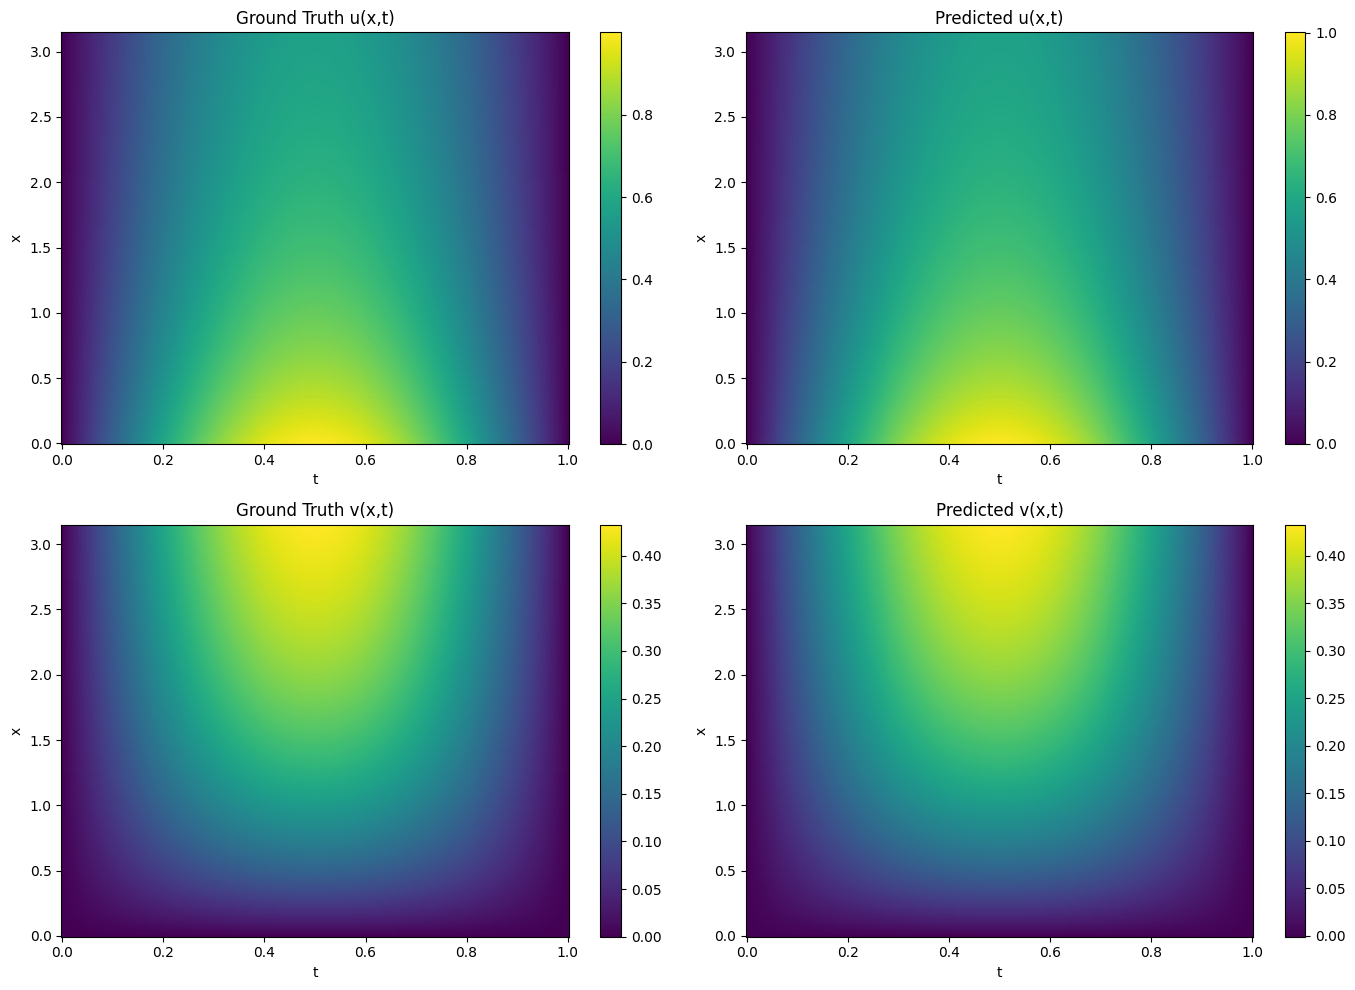

In [82]:
u_true = exact_soln[:, 0].reshape ( nt, nx )
v_true = exact_soln[:, 1].reshape ( nt, nx )

u_pred = model_pred[:, 0].reshape ( nt, nx )
v_pred = model_pred[:, 1].reshape ( nt, nx )

x_plot = x_sample
t_plot = t_sample

fig, axs = plt.subplots ( 2, 2, figsize = ( 14, 10 ) )

im0 = axs[0, 0].pcolormesh ( t_plot, x_plot, u_true, shading = 'auto' )
axs[0, 0].set_title ( "Ground Truth u(x,t)" )
axs[0, 0].set_xlabel ( "t" )
axs[0, 0].set_ylabel ( "x" )
fig.colorbar ( im0, ax = axs[0, 0] )

im1 = axs[0, 1].pcolormesh ( t_plot, x_plot, u_pred, shading = 'auto' )
axs[0, 1].set_title ( "Predicted u(x,t)" )
axs[0, 1].set_xlabel ( "t" )
axs[0, 1].set_ylabel ( "x" )
fig.colorbar ( im1, ax = axs[0, 1] )

im2 = axs[1, 0].pcolormesh ( t_plot, x_plot, v_true, shading = 'auto' )
axs[1, 0].set_title ( "Ground Truth v(x,t)" )
axs[1, 0].set_xlabel ( "t" )
axs[1, 0].set_ylabel ( "x" )
fig.colorbar ( im2, ax = axs[1, 0] )

im3 = axs[1, 1].pcolormesh ( t_plot, x_plot, v_pred, shading = 'auto' )
axs[1, 1].set_title ( "Predicted v(x,t)" )
axs[1, 1].set_xlabel ( "t" )
axs[1, 1].set_ylabel ( "x" )
fig.colorbar ( im3, ax = axs[1, 1] )

plt.tight_layout()
plt.show()
